In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, roc_curve

In [6]:
# 1. Load the CSV file
df = pd.read_csv('C:\\Users\\uppar\\OneDrive\\Desktop\\EmployeeAttrition_UppariMaithri\\HR_Attrition.csv') # Replace with your actual file path

# 2. Display the first 10 rows
display(df.head(10))

# 3. Check rows and columns
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.")

# 4. Identify the target column
target = 'Attrition'

# 5. Count stayed vs left and calculate attrition rate
attrition_counts = df[target].value_counts()
attrition_rate = df[target].value_counts(normalize=True) * 100

print(f"\nAttrition Counts:\n{attrition_counts}")
print(f"Attrition Rate (%):\n{attrition_rate}")

# 6. Identify numeric vs categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"\nNumeric columns: {len(numeric_cols)} | Categorical columns: {len(categorical_cols)}")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Dataset Shape: 1470 rows and 35 columns.

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate (%):
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Numeric columns: 26 | Categorical columns: 9


In [7]:
# 1. Check for missing values
print(f"Missing values:\n{df.isnull().sum().sum()}") # Assuming 0 based on standard IBM dataset

# 2. Drop constant or irrelevant columns
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'] 
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3. Convert target from Yes/No to 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 4. One-Hot Encode categorical columns
# We drop 'Attrition' from this list so we don't encode our target
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"New shape after encoding: {df_encoded.shape}")

Missing values:
0
New shape after encoding: (1470, 45)


In [9]:
# Attrition by Department
print(df.groupby('Department')['Attrition'].mean() * 100)

# Attrition by Job Role
print(df.groupby('JobRole')['Attrition'].mean() * 100)

# Attrition vs Monthly Income
print(df.groupby('Attrition')['MonthlyIncome'].median())

# Attrition vs Work-Life Balance
print(df.groupby('WorkLifeBalance')['Attrition'].mean() * 100)

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64
JobRole
Healthcare Representative     6.870229
Human Resources              23.076923
Laboratory Technician        23.938224
Manager                       4.901961
Manufacturing Director        6.896552
Research Director             2.500000
Research Scientist           16.095890
Sales Executive              17.484663
Sales Representative         39.759036
Name: Attrition, dtype: float64
Attrition
0    5204.0
1    3202.0
Name: MonthlyIncome, dtype: float64
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


In [10]:
# 1. Split Data
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scale numeric features (Doing it here prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train Models with class_weight='balanced' where applicable
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42) # GB handles imbalance intrinsically via sequential trees, though sample_weight can be passed in fit()
}

results = {}

for name, model in models.items():
    # Fit model
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Store metrics
    results[name] = {
        "F1-Score (Class 1)": classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# Display Comparison Table
results_df = pd.DataFrame(results).T
display(results_df)

,F1-Score (Class 1),ROC-AUC
Logistic Regression,0.442748,0.798260
Random Forest,0.142857,0.754716
Gradient Boosting,0.312500,0.794125


In [11]:
# Evaluating the all models with detailed reports
for name, model in models.items():
    print(f"--- {name} ---")
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred), "\n")

# Extracting Feature Importance (Assuming Logistic Regression performed best due to balanced weights yielding better recall)
best_model = models["Logistic Regression"]
importance = best_model.coef_[0]

# Map to features and sort
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(importance)})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(10)

print("\nTop 10 Most Important Features:")
display(feature_importance)

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

Confusion Matrix:
 [[192  55]
 [ 18  29]] 

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

Confusion Matrix:
 [[242   5]
 [ 43   4]] 

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy      

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


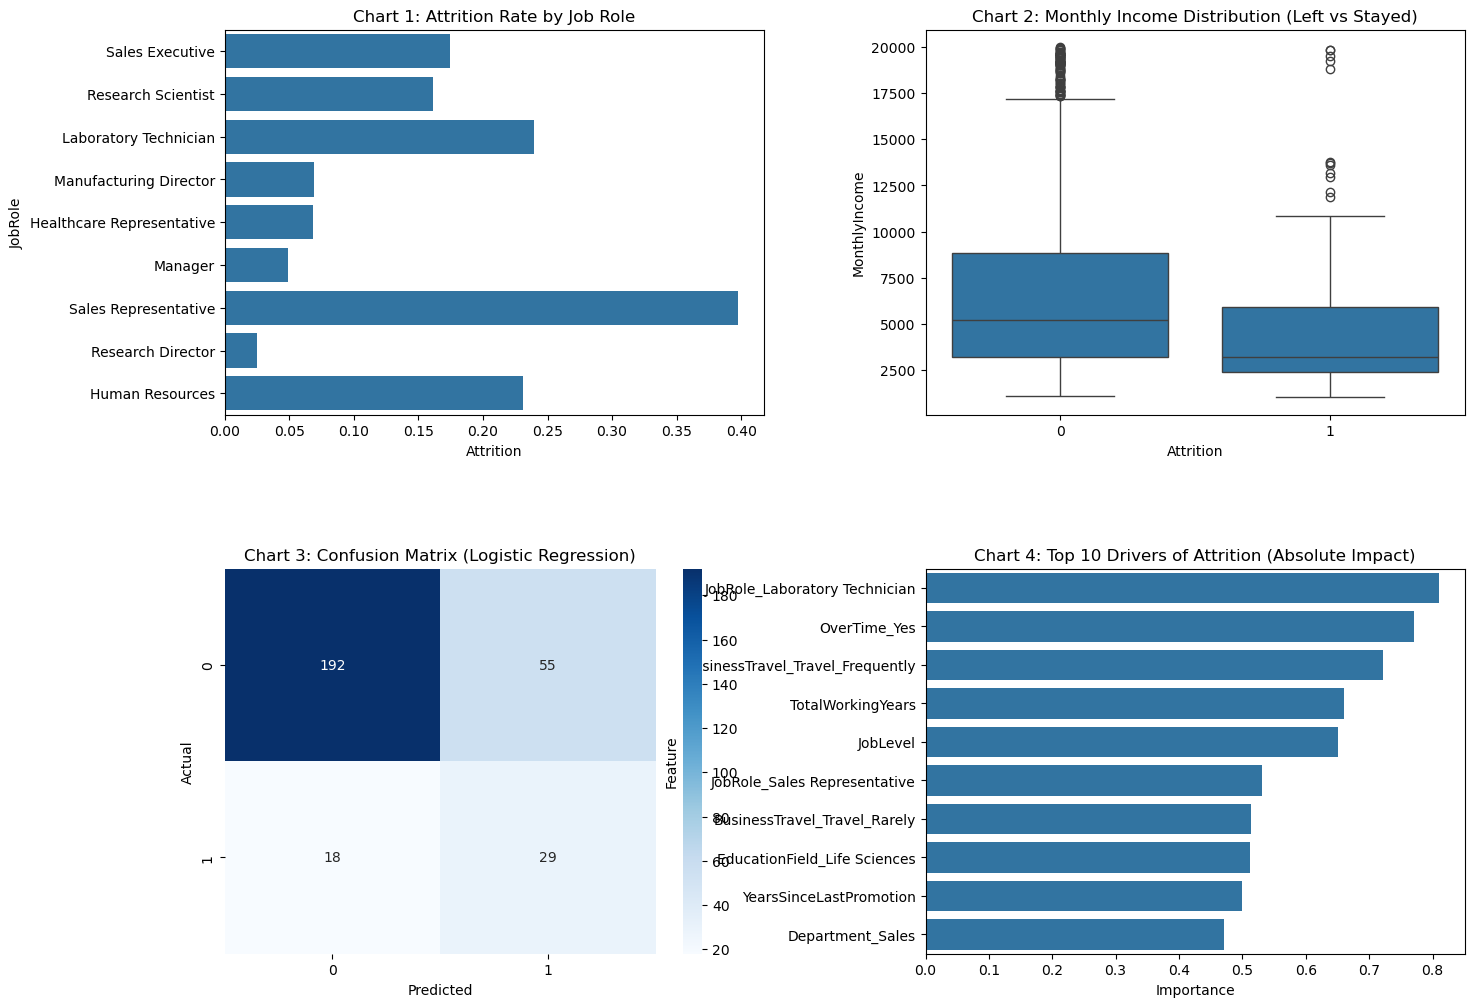

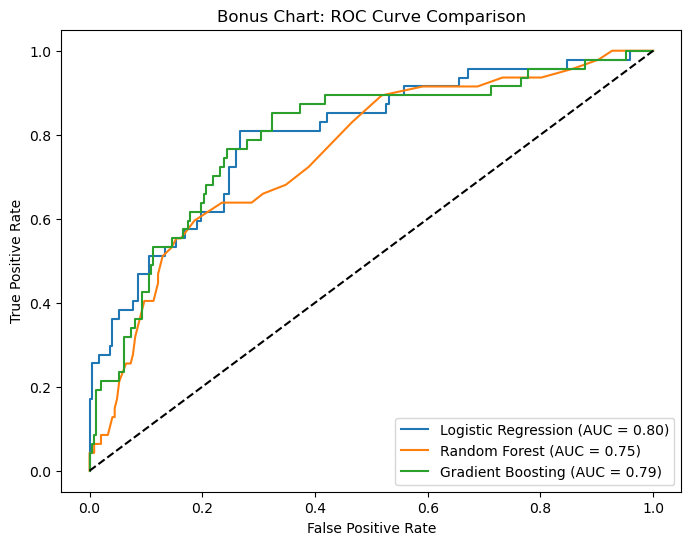

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Chart 1: Attrition by Job Role (using original df for string labels)
sns.barplot(ax=axes[0,0], x='Attrition', y='JobRole', data=df, errorbar=None, orient='h')
axes[0,0].set_title('Chart 1: Attrition Rate by Job Role')

# Chart 2: Box plot Monthly Income vs Attrition
sns.boxplot(ax=axes[0,1], x='Attrition', y='MonthlyIncome', data=df)
axes[0,1].set_title('Chart 2: Monthly Income Distribution (Left vs Stayed)')

# Chart 3: Confusion Matrix Heatmap for Best Model (Logistic Regression)
best_preds = models["Logistic Regression"].predict(X_test_scaled)
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title('Chart 3: Confusion Matrix (Logistic Regression)')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# Chart 4: Top 10 Feature Importances
sns.barplot(ax=axes[1,1], x='Importance', y='Feature', data=feature_importance)
axes[1,1].set_title('Chart 4: Top 10 Drivers of Attrition (Absolute Impact)')

plt.show()

# Chart 5 (Bonus): ROC Curve Comparison
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Bonus Chart: ROC Curve Comparison')
plt.legend()
plt.show()